In [155]:
import pandas as pd

In [156]:
df = pd.read_csv('loan_approval_dataset.csv')

In [157]:
df.shape

(4269, 13)

In [158]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [159]:
df = df.drop_duplicates()

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [161]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [162]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [163]:
df = df.drop('loan_id',axis=1)

In [164]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [165]:
df['loan_status'] = df['loan_status'].map({' Approved':1,' Rejected':0})

In [166]:
df['loan_status'].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [167]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


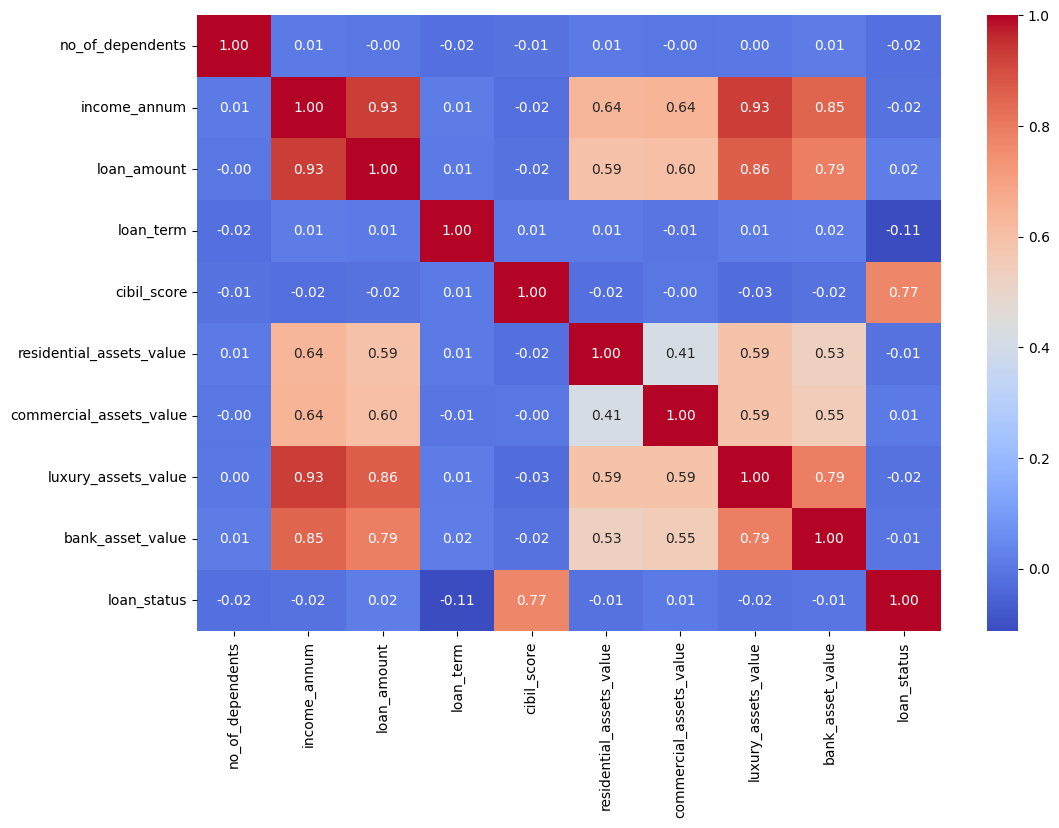

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

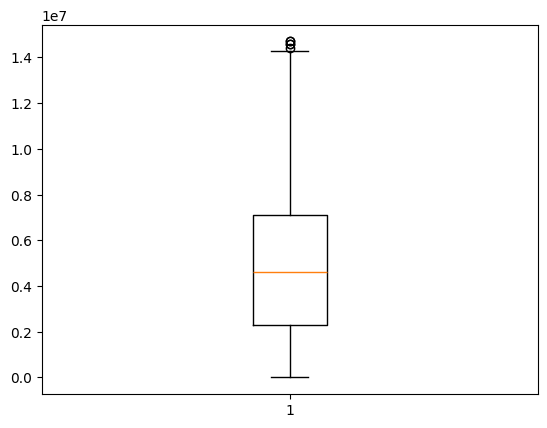

In [169]:
plt.boxplot(df['bank_asset_value'])
plt.show()

In [170]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [171]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [172]:
encode_df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns,drop_first=True,dtype=int)

In [173]:
encode_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,0
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,0
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1,1


In [174]:
X = encode_df.drop('loan_status',axis=1)
y = encode_df['loan_status']

In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [176]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
X_train_scale = rs.fit_transform(X_train)
X_test_scale = rs.transform(X_test)

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, recall_score

lr = LogisticRegression()
lr.fit(X_train_scale, y_train)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('train')
train_acc = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
print(train_acc)
print(train_precision)
print(confusion_matrix(y_train, y_pred_train))

print('#'*10)
print('test')
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
print(test_acc)
print(test_precision)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


result = []

result.append({
    'Model': 'Logistic',
    'train accuracy':train_acc,
    'test accuracy': test_acc,
    'train_precision':train_precision,
    'test precision':test_precision,
    'test recall ': test_recall
})

train
0.9176706827309237
0.9315141787051899
[[1001  128]
 [ 118 1741]]
##########
test
0.9188134270101483
0.9315068493150684
[[429  55]
 [ 49 748]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       484
           1       0.93      0.94      0.94       797

    accuracy                           0.92      1281
   macro avg       0.91      0.91      0.91      1281
weighted avg       0.92      0.92      0.92      1281



In [184]:
from sklearn.svm import SVC

svc = SVC(C=0.31)
svc.fit(X_train_scale, y_train)
y_pred = svc.predict(X_test_scale)
y_pred_train = svc.predict(X_train_scale)

print('train')
train_acc = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
print(train_acc*100)
print(train_precision*100)
print(confusion_matrix(y_train, y_pred_train))

print('#'*10)
print('test')
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
print(test_acc*100)
print(test_precision*100)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
result.append({
    'Model': 'svc',
    'train accuracy':train_acc,
    'test accuracy': test_acc,
    'train_precision':train_precision,
    'test precision':test_precision,
    'test recall ': test_recall
})

train
93.94243641231593
95.49891540130152
[[1046   83]
 [  98 1761]]
##########
test
93.91100702576112
95.56400506970849
[[449  35]
 [ 43 754]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       484
           1       0.96      0.95      0.95       797

    accuracy                           0.94      1281
   macro avg       0.93      0.94      0.94      1281
weighted avg       0.94      0.94      0.94      1281



In [185]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=4,n_jobs=2)
knn.fit(X_train_scale, y_train)
y_pred = knn.predict(X_test_scale)
y_pred_train = knn.predict(X_train_scale)

print('train')
train_acc = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
print(train_acc*100)
print(train_precision*100)
print(confusion_matrix(y_train, y_pred_train))

print('#'*10)
print('test')
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
print(test_acc*100)
print(test_precision*100)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

result.append({
    'Model': 'knn',
    'train accuracy':train_acc,
    'test accuracy': test_acc,
    'train_precision':train_precision,
    'test precision':test_precision,
    'test recall ': test_recall
})

train
92.9384203480589
97.4108170310702
[[1084   45]
 [ 166 1693]]
##########
test
87.43169398907104
93.56164383561644
[[437  47]
 [114 683]]
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       484
           1       0.94      0.86      0.89       797

    accuracy                           0.87      1281
   macro avg       0.86      0.88      0.87      1281
weighted avg       0.88      0.87      0.88      1281



In [186]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=101, max_depth=2,min_samples_split=3)
rf.fit(X_train_scale, y_train)
y_pred = rf.predict(X_test_scale)
y_pred_train = rf.predict(X_train_scale)

print('train')
train_acc = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
print(train_acc*100)
print(train_precision*100)
print(confusion_matrix(y_train, y_pred_train))

print('#'*10)
print('test')
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
print(test_acc*100)
print(test_precision*100)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
result.append({
    'Model': 'rf',
    'train accuracy':train_acc,
    'test accuracy': test_acc,
    'train_precision':train_precision,
    'test precision':test_precision,
    'test recall ': test_recall
})

train
95.21419009370817
99.42396313364056
[[1119   10]
 [ 133 1726]]
##########
test
95.78454332552693
99.59946595460613
[[481   3]
 [ 51 746]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       484
           1       1.00      0.94      0.97       797

    accuracy                           0.96      1281
   macro avg       0.95      0.96      0.96      1281
weighted avg       0.96      0.96      0.96      1281



In [187]:
results = pd.DataFrame(result)
results

,Model,train accuracy,test accuracy,train_precision,test precision,test recall
0,Logistic,0.917671,0.918813,0.931514,0.931507,0.938519
1,svc,0.939424,0.939110,0.954989,0.955640,0.946048
2,knn,0.929384,0.874317,0.974108,0.935616,0.856964
3,rf,0.952142,0.957845,0.994240,0.995995,0.936010
